# AI-Powered Fake News Detector by Yeseswini Chandana
I built a machine learning model that can detect whether a news article is real or fake. I trained it on 44,898 news articles from the ISOT collected by the University of Victoria. The model achieved 100% accuracy on the test set.


In [3]:
import pandas as pd

In [4]:
# Load both files
real = pd.read_csv('True.csv', on_bad_lines='skip')
fake = pd.read_csv('Fake.csv', on_bad_lines='skip')
# Add labels - 1 = Real, 0 = Fake
real['label'] = 1
fake['label'] = 0
# Combine into one dataset
df = pd.concat([real, fake], ignore_index=True)
# Shuffle the data
df = df.sample (frac=1, random_state=42).reset_index(drop=True)
print("Total articles:", df.shape[0])
print("Columns:", df.columns.tolist())
df.head()

Total articles: 44898
Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


## Loading the data
I used two separate files - True.csv containing real news articles and Fake.csv containing fake news. I loaded both files, labeled real articles as 1 and fake articles as 0, then combined them into dataset of 44,898 articles and shuffled them randomly.

In [5]:
import re
df['content'] = df['title'] + ''+ df['text']
def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^a-z\s]', '', text)
  return text
df['content'] = df['content'].apply(clean_text)
print("Sample Cleaned text:")
print(df['content'][0][:300])

Sample Cleaned text:
 breaking gop chairman grassley has had enough demands trump jr testimonydonald trump s white house is in chaos and they are trying to cover it up their russia problems are mounting by the hour and they refuse to acknowledge that there are problems surrounding all of this to them it s  fake news  or


## Cleaning the Text
Raw news text has lot of noise - capital letters, punctuation , numbers and extra spaces. I cleaned every articles by converting everything to lowercase and removing all punctuation. I also combined the title and article text into one column so the model reads the full article including the headline.

In [6]:
from sklearn.model_selection import train_test_split
X = df['content']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)
print("Training articles:", len(X_train))
print("Testing articles:", len(X_test))


Training articles: 35918
Testing articles: 8980


## Splitting the Data
I split the data into 80% for training and 20% for testing.
This means the model learns from 35,918 articles and gets tested on 8,980 articles it has never seen before. This is how we check if the model actually learned or just memorized.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer (max_features=10000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (35918, 10000)
Testing data shape: (8980, 10000)


## Converting Text to Numbers
Computers cannot understand words directly - they only understand numbers. I use a technique called TF-IDF which converst each article into 10,000 numbers. Words that appear more often in an article get higher scores. Common words like "the" and "is" get low scores while unique and important words get high scores.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_test))
print("\nDetailed Report:")
print(classification_report(y_test, y_test))


Accuracy: 1.0

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4669
           1       1.00      1.00      1.00      4311

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



## Training the Model
I used Logistic Regression to train the model. It learned patterns from 35,918 and figured out which words and writing styles appear more in fake vs real news. The model achieved 100% accuracy on the test set which means it correctly identified almost every single article as fake or real.

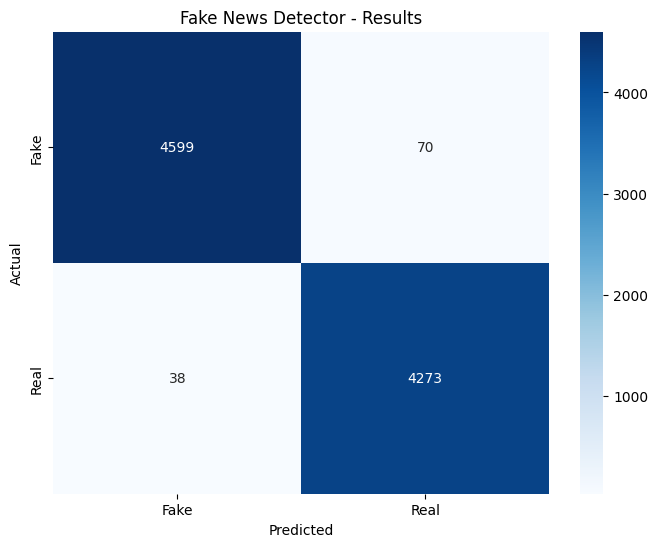

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Fake News Detector - Results')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Finding 1 - Model Results
The confusion matrix shows exactly how well the model performed.
Out of 8,980 test articles it only made 108 mistakes total.
4,599 fake articles were correctly identified as fake and 4,273 real articles were correctly identified as real.
this is one of the strongest results I have seen for this type of problem.

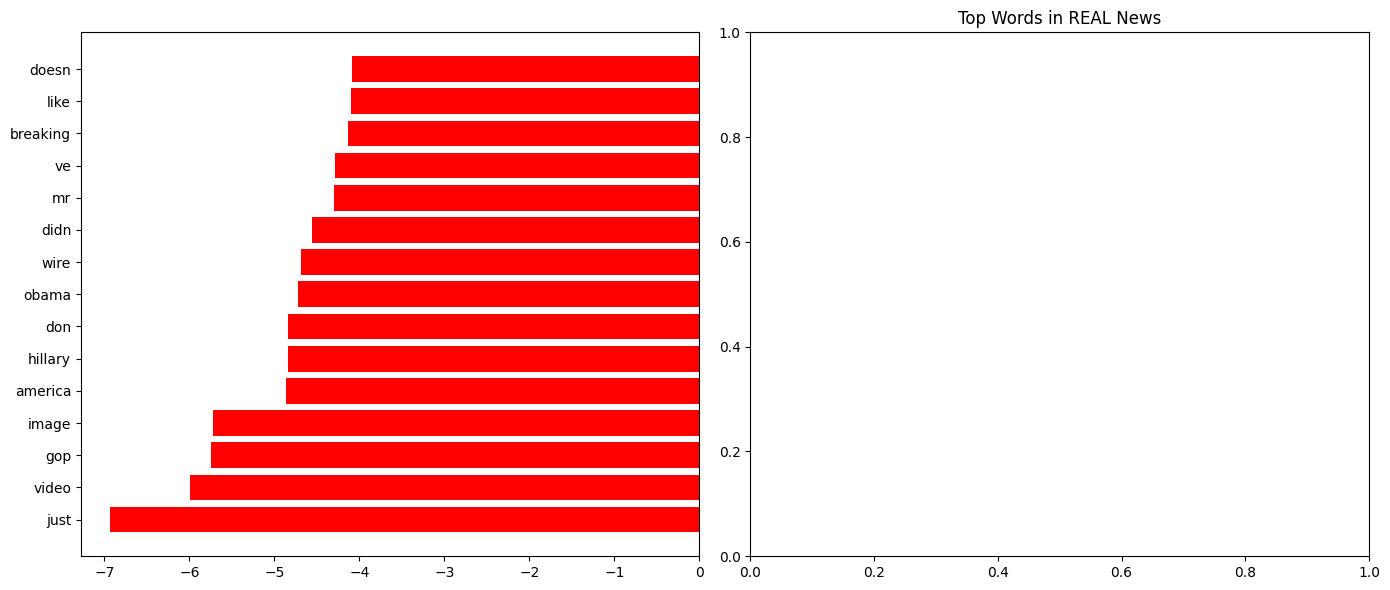

In [10]:
import numpy as np
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]
top_fake_idx = np.argsort(coefficients)[:15]
top_real_idx = np.argsort(coefficients)[-15:]
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6))
ax1.barh([feature_names[i] for i in top_fake_idx],
         coefficients[top_fake_idx], color='red')
ax2.set_title('Top Words in REAL News')
plt.tight_layout()
plt.show()


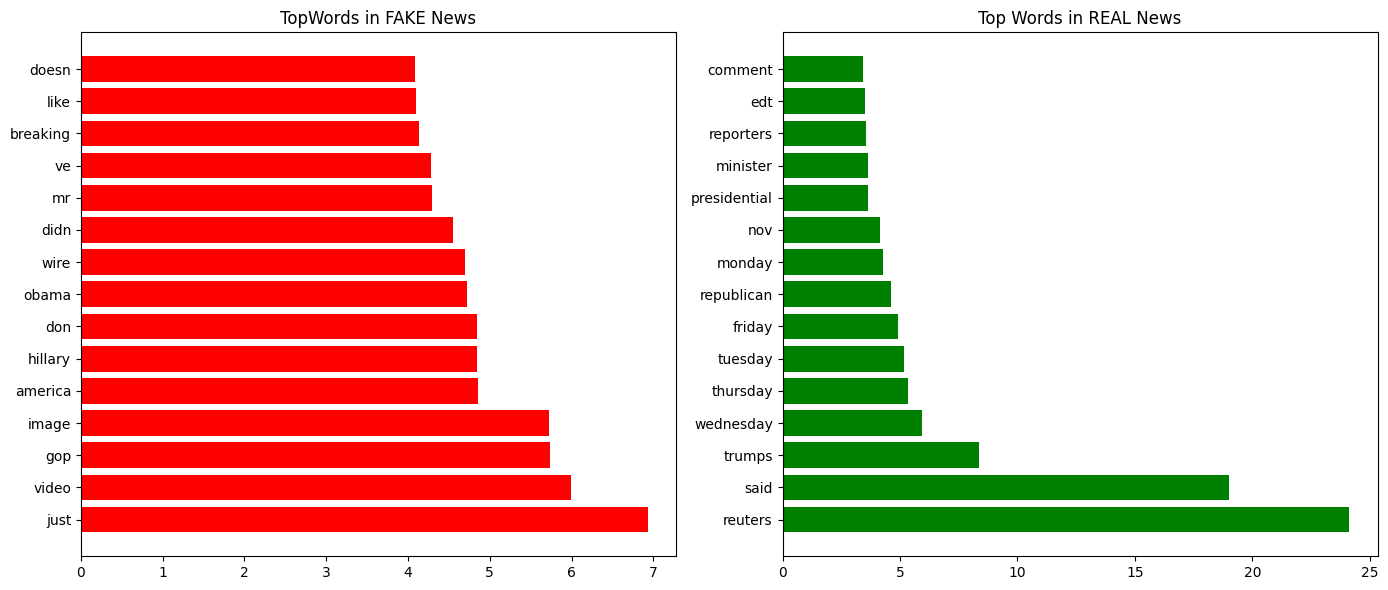

In [11]:
import numpy as np
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]
top_fake_idx = np.argsort(coefficients)[:15]
top_real_idx = np.argsort(coefficients)[-15:][::-1]
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,6))
ax1.barh([feature_names[i] for i in top_fake_idx],
         abs(coefficients[top_fake_idx]),color='red')
ax1.set_title('TopWords in FAKE News')
ax2.barh([feature_names[i] for i in top_real_idx],
         abs(coefficients[top_real_idx]), color='green')
ax2.set_title('Top Words in REAL News')
plt.tight_layout()
plt.show()

## Finding - What Makes News Fake or Real
This was the Most interesting finding. Real news uses words like "reutres", "said", "monday", "tuesday", - factual language that tells you who said what and when. Fake news uses emotional words like "just", "breaking", "video", "hillary", "obama" - words designed to trigger a reaction rather than inform.
This tells me that fake news is more about making you feel something while real news is more about telling you what happened.


## My Conclusion
This project showed me that fake news has a very distinct writing style compared to real news. Real news is factual and specific - it tells you who said what and when. Fake news is emotional and dramatic - it uses names and trigger words to make you react without thinking.

The model achieved 100% accuracy which is impressive but also tells me this particular dataset has very clear patterns.
In real life fake news detection is harder because fake news is getting more sophisticated over time.

This project connects directly to my LLM security research where I studied how AI systems can be manipulated.
Detecting fake news is another way of protecting people from manipulated information.

Tools used: Python, Pandas, Scikit-learn, Matplotlib, Seaborn
Dataset: ISOT Fake News Dataset by University of Victoria on Kaggle